In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

In [2]:
# read in data
data_new_worth = pd.read_csv("../Data/net_worth_cleaned.csv", encoding='ISO-8859-1', index_col='observation_date', parse_dates=True)
data_unemployment = pd.read_csv("../Data/unemployment_cleaned.csv", encoding='ISO-8859-1', index_col='observation_date', parse_dates=True)

In [3]:
# align the two datasets and split into training and testing sets
data_new_worth, data_unemployment = data_new_worth.align(data_unemployment, join='inner', axis=0)
data_new_worth = data_new_worth.asfreq('QS')
data_unemployment = data_unemployment.asfreq('QS')
last_year = data_new_worth.index.year.max() # get the last year in the dataset to use as the test set
train = data_new_worth.index.year < last_year
test  = data_new_worth.index.year == last_year

# create training and testing sets for both datasets
unemployment_train = data_unemployment[train]
unemployment_test  = data_unemployment[test]

train_all = data_new_worth[train]
test_all  = data_new_worth[test]

In [4]:
# fit a linear regression model for each net worth group and evaluate the results
results = []
models = {} # for plotting

# loop through each net worth group and fit a linear regression model using the unemployment data as the predictor
for y_col in data_new_worth.columns:
    y_train = train_all[y_col]
    y_test  = test_all[y_col]

    # fit the linear regression model
    model = LinearRegression()
    model.fit(unemployment_train, y_train)

    # make predictions and evaluate the model
    y_pred = model.predict(unemployment_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    percent_error = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    models[y_col] = model # store the model for later plotting

    results.append({
        'Net Worth Group': y_col,
        'RMSE': rmse,
        'R^2': r2,
        'Percent Error (%)': percent_error
    })

In [5]:
results_df = pd.DataFrame(results)
print(results_df)

  Net Worth Group          RMSE         R^2  Percent Error (%)
0    99% to 99.9%  1.354903e+07 -132.151692          46.781826
1       0% to 50%  2.462370e+06 -497.262308          59.391242
2      90% to 99%  2.773789e+07 -200.387380          45.162970
3      50% to 90%  2.336207e+07 -565.243052          46.667026
4   99.9% to 100%  1.281595e+07 -130.929682          53.817736


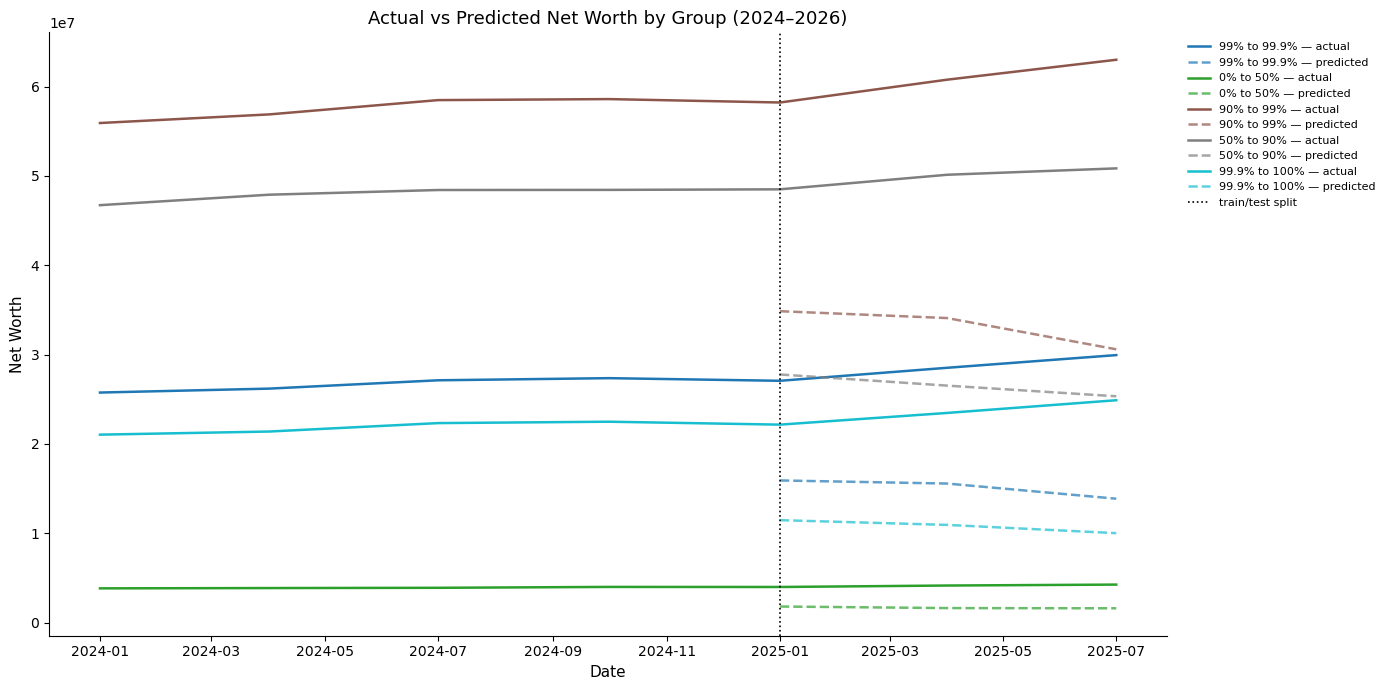

In [6]:
# create graph show predictions vs actual values for each net worth group
# combined on one graph for easier comparison
# showing only 2024-2026

# combine train and test so actuals span full range
all_actual = pd.concat([train_all, test_all])
all_unemployment = pd.concat([unemployment_train, unemployment_test])

mask_all  = (all_actual.index >= '2024-01-01') & (all_actual.index <= '2026-12-31')
mask_test = (unemployment_test.index >= '2024-01-01') & (unemployment_test.index <= '2026-12-31')

actual_filtered = all_actual.loc[mask_all]
unemployment_filtered = unemployment_test.loc[mask_test]

fig, ax = plt.subplots(figsize=(14, 7))
colors = cm.tab10(np.linspace(0, 1, len(data_new_worth.columns)))

for y_col, color in zip(data_new_worth.columns, colors):
    # actuals span full 2024-2026
    ax.plot(actual_filtered.index, actual_filtered[y_col],
            color=color, linewidth=1.8, label=f"{y_col} — actual")

    # predictions only on test dates
    y_pred = models[y_col].predict(unemployment_filtered)
    ax.plot(unemployment_filtered.index, y_pred,
            color=color, linewidth=1.8, linestyle="--", alpha=0.7,
            label=f"{y_col} — predicted")

# vertical line showing train/test split
test_start = test_all.index.min()
ax.axvline(test_start, color="black", linestyle=":", linewidth=1.2, label="train/test split")

ax.set_title("Actual vs Predicted Net Worth by Group (2024–2026)", fontsize=13)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Net Worth", fontsize=11)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
# fit an ARIMA model for each net worth group and evaluate the results
train = (data_new_worth.index.year >= 2004) & (data_new_worth.index.year <= 2024)
test = (data_new_worth.index.year >= 2025)

y_train_all = data_new_worth[train]
y_test_all  = data_new_worth[test]

X_train_all = data_unemployment[train]
X_test_all  = data_unemployment[test]

In [8]:
from statsmodels.tsa.stattools import adfuller

for y_col in y_train_all.columns:
    result = adfuller(y_train_all[y_col].dropna())
    print(f"{y_col}: p-value = {result[1]:.4f} ({'non-stationary, use d=1' if result[1] > 0.05 else 'stationary, use d=0'})")

99% to 99.9%: p-value = 0.9990 (non-stationary, use d=1)
0% to 50%: p-value = 0.9839 (non-stationary, use d=1)
90% to 99%: p-value = 0.9990 (non-stationary, use d=1)
50% to 90%: p-value = 0.9990 (non-stationary, use d=1)
99.9% to 100%: p-value = 1.0000 (non-stationary, use d=1)


In [9]:
# fit an ARIMA model for each net worth group using the unemployment data as the exogenous variable
model_fits = {}

for y_col in y_train_all.columns:
    for x_col in X_train_all.columns:
        y_train = y_train_all[y_col].dropna()
        X_train = X_train_all[[x_col]].loc[y_train.index]
        
        try:
            model = ARIMA(y_train, exog=X_train, order=(1,1,1))
            model_fit = model.fit()
            model_fits[(y_col, x_col)] = model_fit
            print(f"Fitted: {y_col} ~ {x_col}")
        except Exception as e:
            print(f"Skipped {y_col} ~ {x_col}: {e}")

Fitted: 99% to 99.9% ~ 20-24
Fitted: 99% to 99.9% ~ 25-34
Fitted: 99% to 99.9% ~ 35-44
Fitted: 99% to 99.9% ~ 45-54
Fitted: 99% to 99.9% ~ 55 & Over
Fitted: 0% to 50% ~ 20-24
Fitted: 0% to 50% ~ 25-34
Fitted: 0% to 50% ~ 35-44
Fitted: 0% to 50% ~ 45-54
Fitted: 0% to 50% ~ 55 & Over
Fitted: 90% to 99% ~ 20-24
Fitted: 90% to 99% ~ 25-34
Fitted: 90% to 99% ~ 35-44
Fitted: 90% to 99% ~ 45-54
Fitted: 90% to 99% ~ 55 & Over
Fitted: 50% to 90% ~ 20-24
Fitted: 50% to 90% ~ 25-34
Fitted: 50% to 90% ~ 35-44
Fitted: 50% to 90% ~ 45-54
Fitted: 50% to 90% ~ 55 & Over
Fitted: 99.9% to 100% ~ 20-24
Fitted: 99.9% to 100% ~ 25-34
Fitted: 99.9% to 100% ~ 35-44
Fitted: 99.9% to 100% ~ 45-54
Fitted: 99.9% to 100% ~ 55 & Over


In [10]:
# make predictions using the fitted ARIMA models
predictions = {}

# loop through each fitted model and make predictions for the test set
for (y_col, x_col), model_fit in model_fits.items():
    X_test = X_test_all[[x_col]]
    try:
        forecast = model_fit.forecast(steps=len(X_test), exog=X_test)
        predictions[(y_col, x_col)] = forecast
    except Exception as e:
        print(f"Forecast failed for {y_col} ~ {x_col}: {e}")

In [11]:
rows = []

# create a DataFrame to compare the forecasts with the actual values
for (y_col, x_col), pred in predictions.items():
    for date, value in zip(pred.index, pred.values):
        rows.append({
            'Date': date,
            'Net Worth (y)': y_col,
            'Unemployment (x)': x_col,
            'Forecast': value,
            'Actual': y_test_all.loc[date, y_col]
        })

# convert the list of rows into a DataFrame for easier analysis
forecast_df = pd.DataFrame(rows)

# typecast forecast to numeric and remove scientific notation for better readability
pd.options.display.float_format = '{:.0f}'.format
forecast_df['Forecast'] = pd.to_numeric(forecast_df['Forecast'], errors='coerce')
                                        
print(forecast_df)

         Date  Net Worth (y) Unemployment (x)  Forecast    Actual
0  2025-01-01   99% to 99.9%            20-24  27581101  27062861
1  2025-04-01   99% to 99.9%            20-24  27804706  28519246
2  2025-07-01   99% to 99.9%            20-24  28030646  29938926
3  2025-01-01   99% to 99.9%            25-34  27576806  27062861
4  2025-04-01   99% to 99.9%            25-34  27795320  28519246
..        ...            ...              ...       ...       ...
70 2025-04-01  99.9% to 100%            45-54  22901779  23464241
71 2025-07-01  99.9% to 100%            45-54  23102915  24887247
72 2025-01-01  99.9% to 100%        55 & Over  22686695  22154938
73 2025-04-01  99.9% to 100%        55 & Over  22893423  23464241
74 2025-07-01  99.9% to 100%        55 & Over  23097688  24887247

[75 rows x 5 columns]


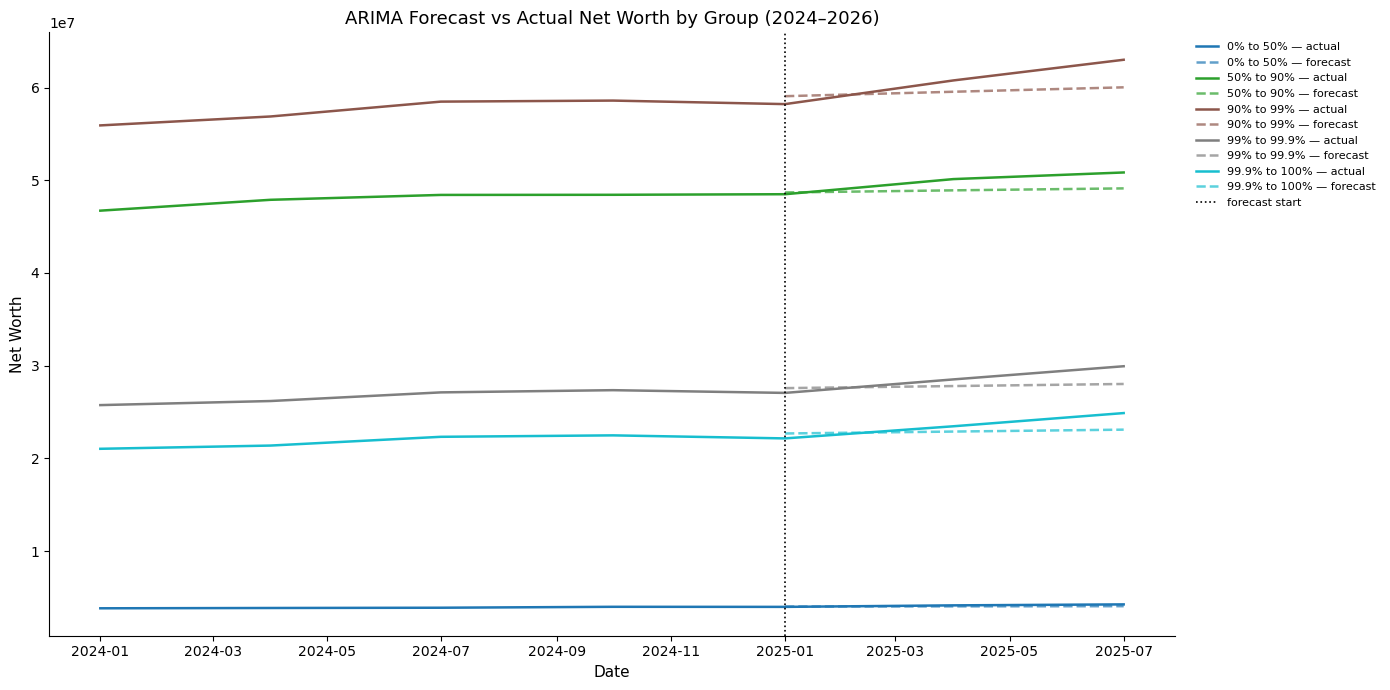

In [12]:
forecast_avg = (
    forecast_df
    .groupby(['Date', 'Net Worth (y)'])[['Forecast', 'Actual']]
    .mean()
    .reset_index()
    .sort_values('Date')
)

# filter to 2024-2026
mask_all      = (all_actual.index >= '2024-01-01') & (all_actual.index <= '2026-12-31')
actual_filtered   = all_actual.loc[mask_all]
forecast_filtered = forecast_avg[
    (forecast_avg['Date'] >= '2024-01-01') &
    (forecast_avg['Date'] <= '2026-12-31')
]

fig, ax = plt.subplots(figsize=(14, 7))
colors = cm.tab10(np.linspace(0, 1, len(forecast_filtered['Net Worth (y)'].unique())))

for y_col, color in zip(forecast_filtered['Net Worth (y)'].unique(), colors):
    group = forecast_filtered[forecast_filtered['Net Worth (y)'] == y_col]

    # actuals from all_actual so they span full 2024-2026
    ax.plot(actual_filtered.index, actual_filtered[y_col],
            color=color, linewidth=1.8, label=f"{y_col} — actual")

    # forecasts only on test dates
    ax.plot(group['Date'], group['Forecast'],
            color=color, linewidth=1.8, linestyle="--", alpha=0.7,
            label=f"{y_col} — forecast")

# vertical line at forecast start
forecast_start = forecast_filtered['Date'].min()
ax.axvline(forecast_start, color="black", linestyle=":", linewidth=1.2, label="forecast start")

ax.set_title("ARIMA Forecast vs Actual Net Worth by Group (2024–2026)", fontsize=13)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Net Worth", fontsize=11)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [13]:
results = []

# evaluate the predictions by calculating RMSE, R^2, and percent error for each net worth group and unemployment predictor
for (y_col, x_col), pred in predictions.items():
    actual = y_test_all[y_col].loc[pred.index]
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)
    percent_error = np.mean(np.abs((actual - pred) / actual)) * 100
    results.append({
        'Net Worth (y)': y_col,
        'Unemployment (x)': x_col,
        'RMSE': rmse,
        'R^2': r2,
        'Percent Error (%)': percent_error
    })

# convert the results into a DataFrame for better visualization
pd.options.display.float_format = '{:.3f}'.format
results_df = pd.DataFrame(results)
print(results_df)

    Net Worth (y) Unemployment (x)        RMSE    R^2  Percent Error (%)
0    99% to 99.9%            20-24 1213901.869 -0.069              3.598
1    99% to 99.9%            25-34 1216761.476 -0.074              3.607
2    99% to 99.9%            35-44 1220435.984 -0.080              3.609
3    99% to 99.9%            45-54 1212626.651 -0.067              3.593
4    99% to 99.9%        55 & Over 1217246.331 -0.075              3.604
5       0% to 50%            20-24  128464.656 -0.356              2.653
6       0% to 50%            25-34  128710.172 -0.361              2.657
7       0% to 50%            35-44  128754.974 -0.362              2.655
8       0% to 50%            45-54  128534.001 -0.358              2.654
9       0% to 50%        55 & Over  128372.434 -0.354              2.650
10     90% to 99%            20-24 1919707.651  0.035              2.733
11     90% to 99%            25-34 1920652.346  0.034              2.735
12     90% to 99%            35-44 1925034.095  0.0

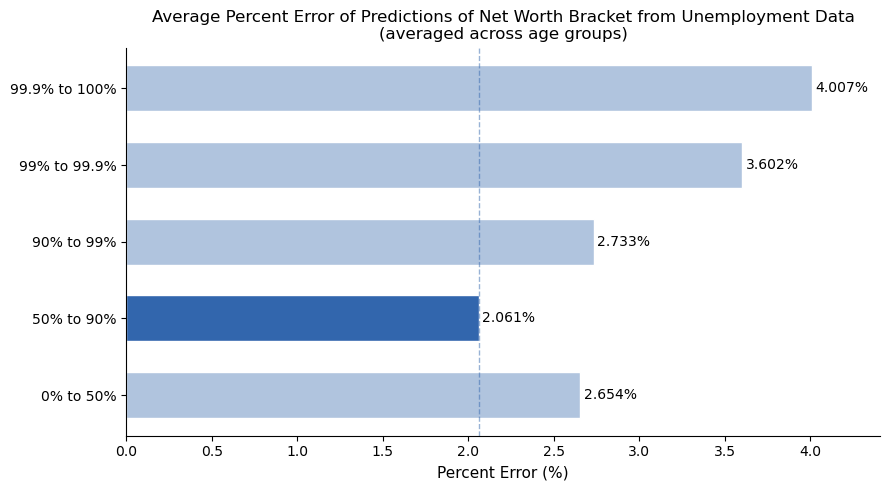

In [14]:
# visualize the average percent error by net worth bracket

# create brackets
from matplotlib import colors


brackets = [
    "0% to 50%",
    "50% to 90%",
    "90% to 99%",
    "99% to 99.9%",
    "99.9% to 100%",
]

# Average percent error across all age groups per bracket
bracket_avg = (
    results_df
    .groupby("Net Worth (y)")["Percent Error (%)"]
    .mean()
    .reset_index()
    .sort_values("Percent Error (%)")   # best (lowest) at top
)

# Sort by wealth order instead of by error value
bracket_avg["order"] = bracket_avg["Net Worth (y)"].map(
    {v: i for i, v in enumerate(brackets)}
)

bracket_avg = bracket_avg.sort_values("order", ascending=False)  # ascending=False so top of chart = wealthiest

brackets   = bracket_avg["Net Worth (y)"].tolist()
pct_errors = bracket_avg["Percent Error (%)"].tolist()

colors = ["#3266ad" if v == min(pct_errors) else "#b0c4de" for v in pct_errors]

# create a horizontal bar chart to visualize the percent errors by bracket
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(brackets, pct_errors, color=colors, edgecolor="white", height=0.6)

# add percent error labels to the bars
for bar, val in zip(bars, pct_errors):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}%", va="center", fontsize=10)

# label plot and customize axes
ax.set_xlabel("Percent Error (%)", fontsize=11)
ax.set_title("Average Percent Error of Predictions of Net Worth Bracket from Unemployment Data\n(averaged across age groups)", fontsize=12)
ax.set_xlim(0, max(pct_errors) + 0.4)
ax.axvline(min(pct_errors), color="#3266ad", linestyle="--", linewidth=1, alpha=0.5)
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)

# plot the figure
plt.tight_layout()
plt.show()

Age group has little effect on net worth bracket. % error spreads were +/- 0.1%